<a href="https://colab.research.google.com/github/reyhan1997/Transaction-data-exploration/blob/main/transactions_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
url = 'https://raw.githubusercontent.com/reyhan1997/Transaction-data-exploration/refs/heads/main/Transactions.csv'
import numpy as np
import pandas as pd
df = pd.read_csv(url)

In [104]:
df.shape

(62884, 31)

In [105]:
#Identify type of input for each column and count the total input non-null (not empty cell)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   TransactionID         62884 non-null  int64 
 1   OrderNumber           62884 non-null  int64 
 2   LineItem              62884 non-null  int64 
 3   OrderDate             62884 non-null  object
 4   DeliveryDate          13165 non-null  object
 5   Quantity              62884 non-null  int64 
 6   CustomerID            62884 non-null  int64 
 7   CustomerGender        62884 non-null  object
 8   CustomerName          62884 non-null  object
 9   CustomerCity          62884 non-null  object
 10  CustomerStateCode     62854 non-null  object
 11  CustomerState         62884 non-null  object
 12  CustomerZip           62884 non-null  object
 13  CustomerCountry       62884 non-null  object
 14  CustomerContinent     62884 non-null  object
 15  CustomerDOB           62884 non-null

In [123]:
#Show only 5 rows value for each column
df.head()

,TransactionID,OrderNumber,LineItem,OrderDate,DeliveryDate,Quantity,CustomerID,CustomerGender,CustomerName,CustomerCity,...,ProductID,ProductName,ProductBrand,ProductColor,ProductCost,ProductPrice,ProductSubcategoryID,ProductSubcategory,ProductCategoryID,ProductCategory
0,3660001,366000,1,1/1/2016,NaN,1,265598,Male,Tyler Vaught,London,...,1304,Contoso Lens Adapter M450 White,Contoso,White,31.27,68.00,406,Cameras & Camcorders Accessories,4,Cameras and camcorders
1,3660011,366001,1,1/1/2016,1/13/2016,2,1269051,Male,Frank Upchurch,Auberry,...,1048,A. Datum SLR Camera X136 Silver,A. Datum,Silver,141.47,427.00,402,Digital SLR Cameras,4,Cameras and camcorders
2,3660012,366001,2,1/1/2016,1/13/2016,1,1269051,Male,Frank Upchurch,Auberry,...,2007,Fabrikam Microwave 1.5CuFt X1100 Black,Fabrikam,Black,220.64,665.94,803,Microwaves,8,Home Appliances
3,3660021,366002,1,1/1/2016,1/12/2016,7,266019,Female,Joan Roche,Red Deer,...,1106,Contoso SLR Camera M146 Orange,Contoso,Orange,148.08,322.00,402,Digital SLR Cameras,4,Cameras and camcorders
4,3660022,366002,2,1/1/2016,1/12/2016,1,266019,Female,Joan Roche,Red Deer,...,373,Adventure Works Laptop8.9 E0890 White,Adventure Works,White,166.20,326.00,301,Laptops,3,Computers


In [122]:
#Checklist column name
df.columns.tolist()

['TransactionID',
 'OrderNumber',
 'LineItem',
 'OrderDate',
 'DeliveryDate',
 'Quantity',
 'CustomerID',
 'CustomerGender',
 'CustomerName',
 'CustomerCity',
 'CustomerStateCode',
 'CustomerState',
 'CustomerZip',
 'CustomerCountry',
 'CustomerContinent',
 'CustomerDOB',
 'StoreID',
 'StoreCountry',
 'StoreState',
 'StoreSqMeters',
 'StoreOpenDate',
 'ProductID',
 'ProductName',
 'ProductBrand',
 'ProductColor',
 'ProductCost',
 'ProductPrice',
 'ProductSubcategoryID',
 'ProductSubcategory',
 'ProductCategoryID',
 'ProductCategory']

In [103]:
df["OrderDate"]

,OrderDate
0,1/1/2016
1,1/1/2016
2,1/1/2016
3,1/1/2016
4,1/1/2016
...,...
62879,2/20/2021
62880,2/20/2021
62881,2/20/2021
62882,2/20/2021


In [106]:
df.isnull().sum()

,0
TransactionID,0
OrderNumber,0
LineItem,0
OrderDate,0
DeliveryDate,49719
Quantity,0
CustomerID,0
CustomerGender,0
CustomerName,0
CustomerCity,0


In [107]:
df['CustomerGender'].value_counts("Female")

,proportion
CustomerGender,
Male,0.505757
Female,0.494243


In [108]:
df['ProductPrice'] = df['ProductPrice'].astype(str).str.replace('$', '', regex=False)
df['ProductPrice'] = pd.to_numeric(df['ProductPrice'], errors='coerce')

# Display the data types to confirm the change
display(df['ProductPrice'].dtype)

dtype('float64')

In [109]:
# Check for any missing values introduced by the conversion
display(df['ProductPrice'].isnull().sum())

np.int64(2185)

In [110]:
# Display rows where 'ProductPrice' is NaN to understand the original values
display(df[df['ProductPrice'].isnull()][['ProductPrice', 'ProductCost']].head())

,ProductPrice,ProductCost
6,NaN,$527.53
27,NaN,$331.32
41,NaN,"$1,060.22"
51,NaN,$960.82
67,NaN,"$1,060.22"


In [111]:
display(df['ProductCategory'].unique())

array(['Cameras and camcorders', 'Home Appliances', 'Computers',
       'TV and Video', 'Cell phones', 'Music, Movies and Audio Books',
       'Games and Toys', 'Audio'], dtype=object)

In [112]:
df['ProductCost'] = df['ProductCost'].astype(str).str.replace('$', '', regex=False)
df['ProductCost'] = pd.to_numeric(df['ProductCost'], errors='coerce')

# Display the data types to confirm the change
display(df['ProductCost'].dtype)

dtype('float64')

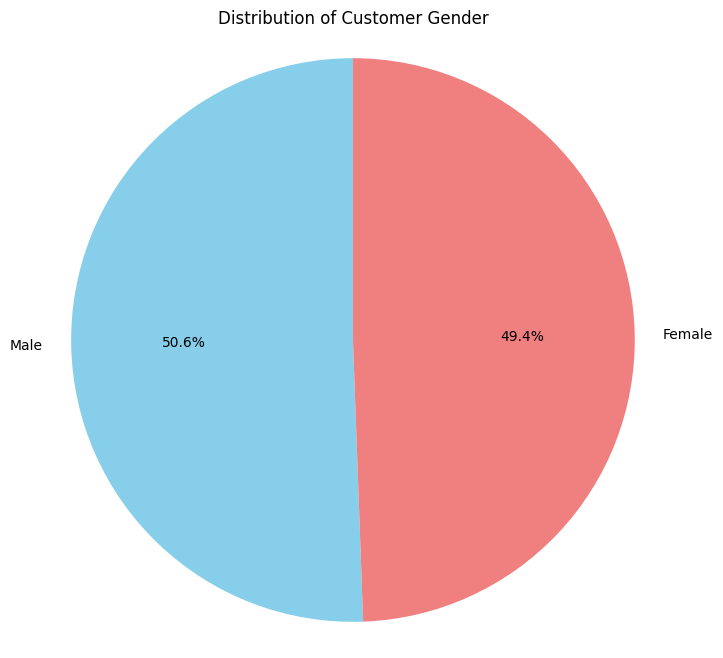

In [113]:
import matplotlib.pyplot as plt

gender_counts = df['CustomerGender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Customer Gender')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [114]:
# Check for any missing values introduced by the conversion
display(df['ProductCost'].isnull().sum())

np.int64(117)

In [115]:
# Display rows where 'ProductPrice' is NaN to understand the original values
display(df['ProductCost'].head())

,ProductCost
0,31.27
1,141.47
2,220.64
3,148.08
4,166.20


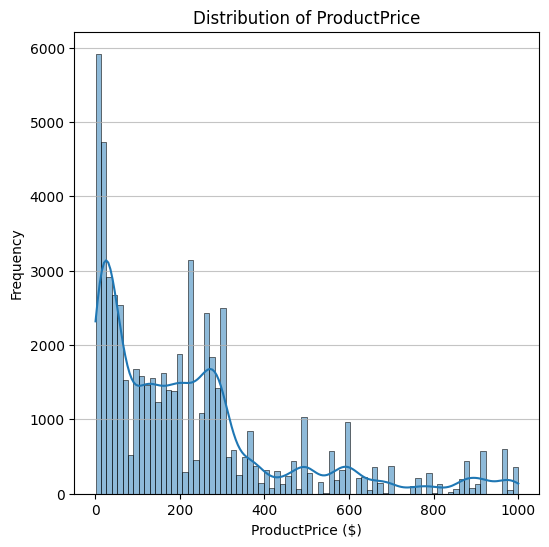

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.histplot(df['ProductPrice'].dropna(), kde=True)
plt.title('Distribution of ProductPrice')
plt.xlabel('ProductPrice ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [117]:
df['ProductCategory'].value_counts()

,count
ProductCategory,
Computers,14025
Cell phones,10158
"Music, Movies and Audio Books",9169
Audio,7489
Games and Toys,7061
Home Appliances,5865
Cameras and camcorders,5559
TV and Video,3558


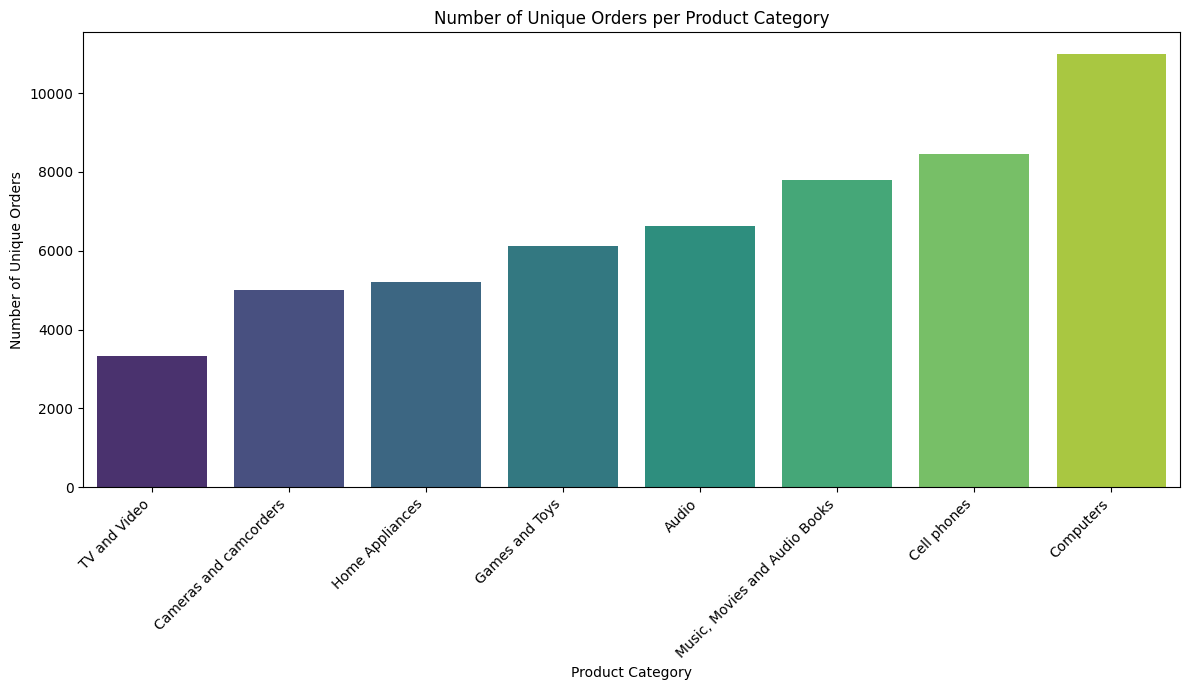

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of unique orders per ProductCategory
orders_per_category = df.groupby('ProductCategory')['OrderNumber'].nunique().sort_values(ascending=True)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=orders_per_category.index, y=orders_per_category.values, hue=orders_per_category.index, palette='viridis', legend=False)
plt.title('Number of Unique Orders per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Unique Orders')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [119]:
top_customers_by_orders = df.groupby(['CustomerID', 'CustomerName'])['OrderNumber'].nunique().sort_values(ascending=False)
top_customers_by_orders.head(25)

,,OrderNumber
CustomerID,CustomerName,
723572,Gaspare Trevisan,14
2080484,Delmer Martinez,12
1349131,Katherine Rosales,11
574327,Jens Himmel,10
2014226,Theodor Kristoffersen,10
1286602,Frances Colbert,10
1388023,David Breton,10
930705,Elizabeth Butler,10
1098687,Edward Rose,10


In [130]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
min_order_date = df['OrderDate'].min()
max_order_date = df['OrderDate'].max()
print(f"OrderDate Min: {min_order_date}")
print(f"OrderDate Max: {max_order_date}")
print(f"OrderDate Range: {max_order_date - min_order_date}")

OrderDate Min: 2016-01-01 00:00:00
OrderDate Max: 2021-02-20 00:00:00
OrderDate Range: 1877 days 00:00:00
